# Importing libraries, general variables, and functions

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install system-level tools required for FastQC and Bowtie2
!apt update
!apt install -y fastqc bowtie2

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,628 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [107 kB]
Get:11 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.7 MB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,164 kB]
Get:14 http://security.ubu

In [3]:
# Install Python packages commonly used across DE and Mutation Detection
!pip install \
numpy==1.26.4 \
pandas==2.2.2 \
scipy==1.14.1 \
cutadapt \
biopython \
pysam
# Session will restart per request by notebook, to accommodate for installed system-level tools, necessary for operation of select DE and Candidate Mutation analysis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.1/281.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.1/106.1 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.4/132.4 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.6/495.6 kB 42.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successful

In [1]:
# Install Python packages specifically for Differential Expression (DE) analysis
!pip install \
anndata==0.10.8 \
zarr==2.18.2 \
pydeseq2==0.4.12 \
formulaic-contrasts==1.0.0 \
numcodecs==0.15.1

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.4/124.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.2/210.2 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 10.6 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=cf93aafa242933ee3fdde7f7e2221f0b7f5c1e8b1e94d29b72b537e602168856
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [2]:
# Import all necessary libraries
from collections import defaultdict
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.default_inference import DefaultInference
from formulaic_contrasts import FormulaicContrasts
from Bio import SeqIO
from scipy import stats
import numpy as np
import seaborn as sns
import shutil
import pysam
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy
import scipy
import pandas
import anndata
import zarr
import pydeseq2
import os

# Functions that are necessary for running DE or candidate substitution analysis or both

In [3]:
# Expands gz files locally
def expandGZ(inputFiles):
  for files in inputFiles:
    !gunzip {files}

# Run FastQC on a given file (can be trimmed or untrimmed)
def fqstQC(inputFiles, directory):
  # Install FastQC once, if not already installed
  !apt install fastqc -y
  for file_path in inputFiles:
    # Extract the base name of the file
    base_name = os.path.basename(file_path)
    # Create a unique output subdirectory for each file
    output_subdir = os.path.join(directory, f'{base_name}_fastqc_results')
    os.makedirs(output_subdir, exist_ok=True)
    # Run FastQC
    !fastqc {file_path} -o {output_subdir}

# Allows download of a wanted file in local directories
def download_files(inputFiles):
  for file_name in inputFiles:
    if os.path.exists(file_name):
        files.download(file_name)

# Normalization (RPM)
def normalization(number, totalReads):
  number = round((number/totalReads)*(10**6))
  return number

# Moves files to a directory
def moving(inputFiles, directory):
  for files in inputFiles:
    shutil.move(files, directory)

# Extracts group count number from headers
def num_process(query):
  query = int(query.split('x')[-1]) # i.e. Seq1x20, first collapsed group, 20 genes in this group
  return query

# Trims adapters with cutadapt
def trimmer(input_raw_files, adapter, minLength, maxLength, adapter_Mismatch_Num, min_overlap_adapter_length): ## Input_raw_files gives the input file(s)
  for i in range(len(input_raw_files)):
    output_file = f'trimmed_files_{i+1}_{os.path.basename(input_raw_files[i])}' # Creates names for output trimmed files
    !cutadapt -a {adapter} -O {min_overlap_adapter_length} -m {minLength} -M {maxLength} -n {adapter_Mismatch_Num} -o {output_file} {input_raw_files[i]} # Trims 3' adapters, with given adapter, expected errors, minimum adapter overlap length, min length of sequence after trimming, max length of sequence after trimming, minimum error in adapter mapping, output file and input file

# Collapses redundant sequences by 100% sequence identity, records sequence number x sequences in each group, fastq to fasta, all sequences expected to be high quality
def collapse_reads(input_trimmed_Files, inputFileType):
  for file_path in input_trimmed_Files:
    collapsed_seq_counts = defaultdict(int) # Creates a dictionary to record sequence cluster counts
    for records in SeqIO.parse(file_path, inputFileType): # Extracts the file fastq sequences
      collapsed_seq_counts[str(records.seq)] += 1

    # Writes collapsed file as fasta, and counts each group and classifies as numbers
    with open(f'deduplicated_{os.path.basename(file_path).replace(inputFileType, 'fasta')}', 'w') as f:
      for i, (seq, num) in enumerate(collapsed_seq_counts.items()):
        f.write(f'>Seq{str(i+1)}x{str(num)}\n{seq}\n')

# Extracts and outputs a species specific mature miRNA file
def species_reference(matureFile, species):
    with open(f'{species}_mature.fasta', "w") as output_species_fasta:
      for record in SeqIO.parse(matureFile, 'fasta'):
        if record.id.startswith(species):
          record.seq = record.seq.back_transcribe() # Turns each reference sequence U to T for alignment purposes
          SeqIO.write(record, output_species_fasta, 'fasta') # Writes the species specific mature miRNA reference sequences, with U -> T modifications
    return f'{species}_mature.fasta'

# Bowtie 2, inputting trimmed files, seed region match, number of mismatch, number of returned aligned reads, and alignment style
def bowtie(input_trimmed_Files, aligner, seedLength, num_mismatch_in_seed, num_return_align, align_style):
  # Installs necessary packages and makes alignment file
  !apt update
  !apt install -y bowtie2
  !bowtie2 --version
  !bowtie2-build {aligner} refFiles

  # Main module of the function
  for i in range(len(input_trimmed_Files)):
    input_file = input_trimmed_Files[i]
    file_name = os.path.basename(input_file)
    outputNum = re.search(r"_(\d)_", file_name)
    output_file = f'bowtie{outputNum}.sam' # Makes output bowtie files name
    !bowtie2 -f -x refFiles -U {input_file} -S {output_file} -L {seedLength} -N {num_mismatch_in_seed} -k {num_return_align} {align_style} # f for fasta, x for alignment file, u for input, s for output, l for conserved 'seed', n for mismatch, k only 1 alignment

# Reads samfiles, determines counts of each miRNA group(sequence independent) and outputs CSV files for counts and metadata describing groups
def postBowtie2(inputFiles):
  meta_file_dict = {} # Sets up dictionary for storing metadata file data
  all_miRNA_genes_template = findingTotalGenes(inputFiles) # Get all possible miRNA genes once to avoid errors, set at 0 for all initially
  df = pd.DataFrame(index=all_miRNA_genes_template.keys()) # Use keys for building index for count file
  df.index.name = 'miRNA genes'

  for items in inputFiles:
    current_sample_counts = all_miRNA_genes_template.copy() # Avoids accumulation, makes a fresh copy
    samfile = pysam.AlignmentFile(items, 'r') # Reads SAM files
    for read in samfile.fetch():
      # If gene is aligned, add how many genes in this collapsed group
      if not read.is_unmapped:
        #queryNum = num_process(read.qname) # Extract raw counts from header
        current_sample_counts[str(read.reference_name)] += 1 # Adds the raw counts for specific gene, independent of exact sequence matching

    # Sets up series for counts of genes
    Numbering_of_bowties = int(re.findall(r'\d+', items)[0])
    if Numbering_of_bowties <= (len(inputFiles)/2): # If Bowtie file was a control file

      # Collects counts of sequences and the type of columns for metadata
      inputs = f'Control{Numbering_of_bowties}'
      df[inputs] = pd.Series(current_sample_counts) # Assign the series of counts for the current sample
      meta_file_dict[inputs] = 'Control'
    else: # If Bowtie file was an experimental/high file

      # Collects counts of sequences and the type of columns for metadata
      inputs = f'High{Numbering_of_bowties - 3}'
      df[inputs] = pd.Series(current_sample_counts) # Assign the series of counts for the current sample
      meta_file_dict[inputs] = 'High'

  # Sets up metadata
  dfmeta = pd.DataFrame.from_dict(meta_file_dict, orient='index', columns=['Types'])
  dfmeta.index.name = 'Samples'
  dfmeta.to_csv('metadata_DE.csv', index = True)
  df.to_csv('count_data_DE.csv', index=True)

# Finds the all types of genes, to reduce errors if a gene is not recorded in a dataset
def findingTotalGenes(inputFiles):
  aligned_genes = {}
  for items in inputFiles:
    samfile = pysam.AlignmentFile(items, "r") # Reads SAM files
    for read in samfile.fetch():
      if not read.is_unmapped and read.reference_name not in aligned_genes: # If read is aligned
        aligned_genes[read.reference_name] = 0 # Sets each gene to a count of 0
  return aligned_genes # Returns the dictionary

# Finding total aligned genes
def finding_total_aligned(count_csv):
  finding_total_genes_aligned = defaultdict(int)
  df = pd.read_csv(count_csv, index_col=0)
  for sample_names in df.columns:
    finding_total_genes_aligned[sample_names] = int(np.sum(np.array(df[sample_names])))
  return dict(finding_total_genes_aligned)

# Runs Deseq2 on the count file along with metadata file
def Deseq2(countsFile, metadata_file, analysis_type, total_aligned_genes):
  # Opens and sets up the count file and metadata file
  counts_df = pd.read_csv(countsFile, index_col=0)
  metadata = pd.read_csv(metadata_file, index_col=0)
  # The 'Types' column holds the group information (Control/High), not the index name 'Samples'.
  # The line 'types = metadata.index.name' was the source of the error.
  counts_df = counts_df.T
  common_samples = counts_df.index.intersection(metadata.index)
  counts_df = counts_df.loc[common_samples]
  metadata = metadata.loc[common_samples]

  inference = DefaultInference(n_cpus=6) # Inference to determine meaningful biological changes, set as default PyDESeq inference method

  # Specifically normalize by number of genes for substitution event analysis
  if analysis_type == 'Sub':
    reference_value = total_aligned_genes.mean()
    manual_size_factors = total_aligned_genes / reference_value
    dds.obsm['size_factors'] = manual_size_factors.values

  dds = DeseqDataSet(
      counts=counts_df,
      metadata=metadata,
      design_factors="Types",
      inference=inference
  )

  dds.var_names_make_unique() # Checks to see if each gene group is unique

  dds.deseq2() # Executes core functions on datasets
  # Also correct the DeseqStats contrast to use 'Types' as the factor name
  stat_res = DeseqStats(dds, ['Types', 'High', 'Control'], inference=inference) # Writes dataframe for genes that were determined
  stat_res.summary() # Print out summary
  p_thresh = 0.05 # Set Padj threshold
  fc_thresh = 0.3 # Set LFC threshold

  # Sets up the results files
  results_df = stat_res.results_df

  up = (results_df['padj'] < p_thresh) & (abs(results_df['log2FoldChange']) >= fc_thresh) # Upregulated genes
  down = (results_df['padj'] < p_thresh) & (results_df['log2FoldChange'] <= -(fc_thresh)) # Downregulated genes
  outside = (results_df['padj'] > p_thresh) # not significant or no change genes
  plt.scatter((results_df['log2FoldChange'])[up], (-np.log10(results_df['padj']))[up], label='Upregulated',s=10,color = 'red') # Plots upregulated genes as red
  plt.scatter((results_df['log2FoldChange'])[down], (-np.log10(results_df['padj']))[down], label='Downregulated', s=10, color = 'blue') # Plots downregulated genes as blue
  plt.scatter((results_df['log2FoldChange'])[outside], (-np.log10(results_df['padj']))[outside], label='No cutoff', s=10, color = 'Gray') # Plots non-significant genes as gray

  # Sets bars to differentiate significant and non-significant, and differentiable and non-differentiable genes
  plt.axhline(y=-np.log10(p_thresh), color='green', linestyle='--', linewidth=1)
  plt.axvline(x=fc_thresh, color='green', linestyle='--', linewidth=1)
  plt.axvline(x=-fc_thresh, color='green', linestyle='--', linewidth=1)

  # Sets up labels, title is up to discretion of the user
  plt.xlabel('log2 Fold Change')
  plt.ylabel('-log10 adjusted p-value')
  plt.title(input('What should be the title of this graph made:'))
  plt.legend()
  plt.show()

  # Filters for values meeting specific requirements
  results_df = results_df.sort_values(by='padj', ascending=True)
  results_df = results_df[abs(results_df['log2FoldChange']) > fc_thresh ].sort_values(by='log2FoldChange', ascending=True)
  results_df.to_csv('stats_res.csv', index=True) # Creates the results CSV into local file

# This function extracts aligned miRNA sequences and gives its MD tag, query sequence composition, and aligned sequence name, using these info to determine
def samAnalyzer(inputFiles, aligned_seq_counts): # input SAM files, total aligned sequences in each of the samples
  processed_normalized_dfs = [] # To store dataframes of normalized mutation counts for each SAM file
  processed_raw_dfs = [] # To store dataframes of raw mutation counts for each SAM file
  for file_idx, items in enumerate(inputFiles): # Iterates every SAM file and gives the name and its ranking order
    current_sam_file_detailed_mutations = [] # mutations details storing list-
    seqInfo_base_on_length = [[] for _ in range(18, 26)] # Set sequence information, based on length 18-25
    samfile = pysam.AlignmentFile(items, 'r') # Reads SAM file

    for read in samfile.fetch(until_eof=True):
      if not read.is_unmapped and read.reference_name is not None: # Only if sequences is aligned and has a reference name
        length = len(str(read.seq))
        if 18 <= length <= 25: # Only update length_counts if the length is within range
          md_tag = read.get_tag('MD')
          seq_read = str(read.seq)
          ref_name = str(read.reference_name)

          samInfo = [ref_name, seq_read, str(md_tag), length] # Read aligned name, query sequence, MD tag, length of sequence
          filterLengths(samInfo, seqInfo_base_on_length) # filter SAM info based on lengths


    for info_on_length in seqInfo_base_on_length: # For each length of sequences
        for seqInfo in info_on_length: # for each sequence in length
          current_sam_file_detailed_mutations.extend(get_mismatches(seqInfo[2], seqInfo[1], seqInfo[0])) # Get candidate substitution counts and info

    print(len(current_sam_file_detailed_mutations))
    # After processing all lengths for the current SAM file:
    base_filename = os.path.basename(items) # Extracts basename of the file path
    output_prefix = os.path.splitext(base_filename)[0] # Extract bowtie(\d+)

    if current_sam_file_detailed_mutations:
        # Determine sample column name
        # match = re.search(r'bowtie(\d+)', output_prefix)
        match = re.search(r'TESTMMUC(\d+)', output_prefix)
        num_int = int(match.group(1))
        if num_int <= (len(inputFiles)/2):
            sample_col_name_base = f'Control{num_int}'
        else:
            sample_col_name_base = f'High{int(num_int - (len(inputFiles)/2))}'

        df_current_sam = pd.DataFrame(current_sam_file_detailed_mutations)
        df_current_sam_grouped = df_current_sam.groupby(['miRNA', 'Position', 'Ref_to_Alt'])['Count'].sum().reset_index()

        # Prepare raw DataFrame for merging
        df_current_sam_grouped_raw = df_current_sam_grouped.copy()
        df_current_sam_grouped_raw.rename(columns={'Count': f'{sample_col_name_base}_raw'}, inplace=True)
        processed_raw_dfs.append(df_current_sam_grouped_raw)

        # Prepare normalized DataFrame for merging
        df_current_sam_grouped_normalized = df_current_sam_grouped.copy()
        # Use the constructed sample_col_name_base to get the correct normalization factor
        normalization_factor = aligned_seq_counts[sample_col_name_base]
        df_current_sam_grouped_normalized['Count'] = ((df_current_sam_grouped_normalized['Count'] / normalization_factor) * 1_000_000).round(3)
        df_current_sam_grouped_normalized.rename(columns={'Count': f'{sample_col_name_base}_normalized'}, inplace=True)
        processed_normalized_dfs.append(df_current_sam_grouped_normalized)

  # Combine all processed dataframes into final output
  if processed_normalized_dfs and processed_raw_dfs:
      # Merge all normalized dataframes
      final_normalized_df = processed_normalized_dfs[0]
      for i in range(1, len(processed_normalized_dfs)):
          final_normalized_df = pd.merge(final_normalized_df, processed_normalized_dfs[i], on=['miRNA', 'Position', 'Ref_to_Alt'], how='outer')
      final_normalized_df.fillna(0, inplace=True)

      # Create Mutation_Identifier for normalized data
      final_normalized_df['Mutation_Identifier'] = final_normalized_df['miRNA'].astype(str) + ' | ' + \
                                                   final_normalized_df['Position'].astype(str) + ' | ' + \
                                                   final_normalized_df['Ref_to_Alt'].astype(str)
      # Drop original identifier columns from normalized data
      final_normalized_df.drop(columns=['miRNA', 'Position', 'Ref_to_Alt'], inplace=True)
      # Reorder columns to have the new identifier column first for normalized data
      all_normalized_columns = ['Mutation_Identifier'] + [col for col in final_normalized_df.columns if col != 'Mutation_Identifier']
      final_normalized_df = final_normalized_df[all_normalized_columns]

      # Save the normalized DataFrame
      output_filename_normalized = 'all_mutations_normalized_single_column_id.csv'
      final_normalized_df.to_csv(output_filename_normalized, index=False)
      print(f'Saved normalized mutation data with single identifier column to {output_filename_normalized}')
      display(final_normalized_df.head())


      # Merge all raw dataframes
      final_raw_df = processed_raw_dfs[0]
      for i in range(1, len(processed_raw_dfs)):
          final_raw_df = pd.merge(final_raw_df, processed_raw_dfs[i], on=['miRNA', 'Position', 'Ref_to_Alt'], how='outer')
      final_raw_df.fillna(0, inplace=True)
      # Convert raw counts to int
      for col in final_raw_df.columns:
          if col not in ['miRNA', 'Position', 'Ref_to_Alt']:
              final_raw_df[col] = final_raw_df[col].astype(int)

      # Create index column for raw data
      final_raw_df['Mutation_Identifier'] = final_raw_df['miRNA'].astype(str) + ' | ' + \
                                            final_raw_df['Position'].astype(str) + ' | ' + \
                                            final_raw_df['Ref_to_Alt'].astype(str)
      # Drop original identifier columns from raw data
      final_raw_df.drop(columns=['miRNA', 'Position', 'Ref_to_Alt'], inplace=True)
      # Reorder columns to have the new identifier column first for raw data
      all_raw_columns = ['Mutation_Identifier'] + [col for col in final_raw_df.columns if col != 'Mutation_Identifier']
      final_raw_df = final_raw_df[all_raw_columns]
      final_raw_df.set_index('Mutation_Identifier')
      # Rename the raw columns to remove _raw
      new_cols_raw = []
      for col in final_raw_df.columns:
          if col.endswith('_raw'):
              new_cols_raw.append(col.replace('_raw', ''))
          else:
              new_cols_raw.append(col)
      final_raw_df.columns = new_cols_raw

      # Save the raw DataFrame
      output_filename_raw = 'all_mutations_raw_single_column_id.csv'
      final_raw_df.to_csv(output_filename_raw, index=False)
      print(f'Saved raw mutation data with single identifier column to {output_filename_raw}')
      display(final_raw_df.head())

  else:
      print("No mutation data processed to generate combined output.")

def filterLengths(samInfo, seqInfo_base_on_length):
  length = samInfo[3]
  if 18 <= length <= 25:
    # Correct the index to be 0-based relative to the start length of 18
    seqInfo_base_on_length[length - 18].append(samInfo)

# Determines mismatches, its location, the sequence, and what event type
def get_mismatches(md, seq, sequence_name):
    detected_mutations = [] # Sets a list
    i = 0 # This is for determing position of a mismatch
    # Finds for digit, then a letter or ^
    tokens = re.findall(r'\d+|\^[A-Z]+|[A-Z]', str(md))
    for token in tokens:
        if token.isdigit(): # If its a number
            i += int(token)
        elif token.startswith('^'): # If this is deletion
            continue
        elif i < len(seq) and token != seq[i] and seq[i] != 'N': # If this is mismatch and seq[i] != N
            ref_base = token
            read_base = seq[i]
            mutation_type = f"{ref_base}-{read_base}"
            detected_mutations.append({'miRNA': sequence_name, 'Position': i + 1, 'Ref_to_Alt': mutation_type, 'Count': queryNum})
            i += 1
        elif i < len(seq): # Advance position if no mismatch detected but base was consumed
            i += 1
    return detected_mutations

# DE module specific code

In [ ]:
## Running DE modules on control mice and polystyrene-exposed mice
# Opens up zip files (import gz files into local directory)
'''
# Set up initial files (GZ)
files1 = '/content/SRR12879947.fastq.gz'
files2 = '/content/SRR12879948.fastq.gz'
files3 = '/content/SRR12879949.fastq.gz'
files4 = '/content/SRR12879950.fastq.gz'
files5 = '/content/SRR12879951.fastq.gz'
files6 = '/content/SRR12879952.fastq.gz'
gz_files_list = [files1, files2, files3, files4, files5, files6]
# Expand GZ files
expandGZ(gz_files_list)

# Trims the fastq files
adapter = 'TGGAATTCTCGGGTGCCAAGGAACTCCAG'
files1 = '/content/SRR12879947.fastq'
files2 = '/content/SRR12879948.fastq'
files3 = '/content/SRR12879949.fastq'
files4 = '/content/SRR12879950.fastq'
files5 = '/content/SRR12879951.fastq'
files6 = '/content/SRR12879952.fastq'
raw_files_list = [files1, files2, files3, files4, files5, files6]
#fqstQC(raw_files_list, '/content/fastqc_output')
trimmer(input_raw_files=raw_files_list, adapter=adapter, minLength=18, maxLength=25, adapter_Mismatch_Num=1, min_overlap_adapter_length=7)

# Collapses reads
files1 = '/content/trimmed_files_1_SRR12879947.fastq'
files2 = '/content/trimmed_files_2_SRR12879948.fastq'
files3 = '/content/trimmed_files_3_SRR12879949.fastq'
files4 = '/content/trimmed_files_4_SRR12879950.fastq'
files5 = '/content/trimmed_files_5_SRR12879951.fastq'
files6 = '/content/trimmed_files_6_SRR12879952.fastq'
trimmed_files_list = [files1, files2, files3, files4, files5, files6]
collapse_reads(input_trimmed_Files=trimmed_files_list, inputFileType='fastq')

# Run Bowtie 2 on collapsed files
files1 = '/content/deduplicated_trimmed_files_1_SRR12879947.fasta'
files2 = '/content/deduplicated_trimmed_files_2_SRR12879948.fasta'
files3 = '/content/deduplicated_trimmed_files_3_SRR12879949.fasta'
files4 = '/content/deduplicated_trimmed_files_4_SRR12879950.fasta'
files5 = '/content/deduplicated_trimmed_files_5_SRR12879951.fasta'
files6 = '/content/deduplicated_trimmed_files_6_SRR12879952.fasta'
deduplicated_files_list = [files1, files2, files3, files4, files5, files6]
mmu1_ref = species_reference('/content/mature.fa', 'mmu') # Make mature align reference based on species
# Bowtie on the input files
bowtie(deduplicated_files_list, hsa1_ref, seedLength=7, num_mismatch_in_seed=1, num_return_align=1, align_style='--end-to-end')

# Sets up SAM files
sam1 = '/content/bowtie1.sam'
sam2 = '/content/bowtie2.sam'
sam3 = '/content/bowtie3.sam'
sam4 = '/content/bowtie4.sam'
sam5 = '/content/bowtie5.sam'
sam6 = '/content/bowtie6.sam'
bowtie_list = [sam1, sam2, sam3, sam4, sam5, sam6]

# Make count and metadata files
postBowtie2(bowtie_list)

# Find align gene counts for all samples
aligned_genes = finding_total_aligned('/content/count_data_DE.csv')

# Run PyDESEq2
Deseq2('/content/count_data_DE.csv', '/content/metadata_DE.csv', 'Counts', list(aligned_genes.values()))
# Title of graph: Microplastic DE analysis
'''

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.25 seconds.

Fitting dispersion trend curve...
... done in 0.15 seconds.

Fitting MAP dispersions...
... done in 2.14 seconds.

Fitting LFCs...
... done in 1.34 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.54 seconds.



Log2 fold change & Wald test p-value: Types High vs Control
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
miRNA genes                                                                 
mmu-miR-125b-5p  352.176165       -0.186584  0.126922 -1.470063  0.141545   
mmu-miR-27b-3p    99.620708       -0.116822  0.169158 -0.690611  0.489810   
mmu-let-7a-5p    115.394221        0.054979  0.159606  0.344469  0.730494   
mmu-miR-127-3p   239.289138       -0.101982  0.121707 -0.837926  0.402072   
mmu-miR-29a-3p   184.644173       -0.033656  0.134126 -0.250932  0.801867   
...                     ...             ...       ...       ...       ...   
mmu-miR-1258-3p    0.144125        0.809714  3.809700  0.212540  0.831686   
mmu-miR-3091-3p    0.144125        0.809714  3.809700  0.212540  0.831686   
mmu-miR-5104       0.144125        0.809714  3.809700  0.212540  0.831686   
mmu-miR-7670-3p    0.144125        0.809714  3.809700  0.212540  0.831686   
mmu-miR-511-5p  

Index(['Control1', 'Control2', 'Control3', 'High1', 'High2', 'High3'], dtype='object')
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.92 seconds.

Fitting dispersion trend curve...
/usr/local/lib/python3.12/dist-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 1.63 seconds.

Fitting LFCs...
... done in 0.81 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.37 seconds.



Log2 fold change & Wald test p-value: Types High vs Control
                      baseMean  log2FoldChange     lfcSE      stat    pvalue  \
miRNA genes                                                                    
hsa-miR-10b-5p   233427.229503       -1.466444  0.481597 -3.044961  0.002327   
hsa-miR-10a-5p    51843.188351       -1.132901  0.778240 -1.455722  0.145469   
hsa-miR-192-5p    46365.883343       -0.610868  0.696081 -0.877582  0.380170   
hsa-miR-127-3p      770.901111       -1.335534  0.620180 -2.153460  0.031283   
hsa-miR-27b-3p    34081.420519       -0.222327  0.311633 -0.713427  0.475581   
...                        ...             ...       ...       ...       ...   
hsa-miR-5698          0.173504        1.425647  3.547548  0.401868  0.687781   
hsa-miR-371a-3p       0.173504        1.425647  3.547548  0.401868  0.687781   
hsa-miR-3165          0.173504        1.425647  3.547548  0.401868  0.687781   
hsa-miR-4786-5p       0.173504        1.425647  3.547548  0.

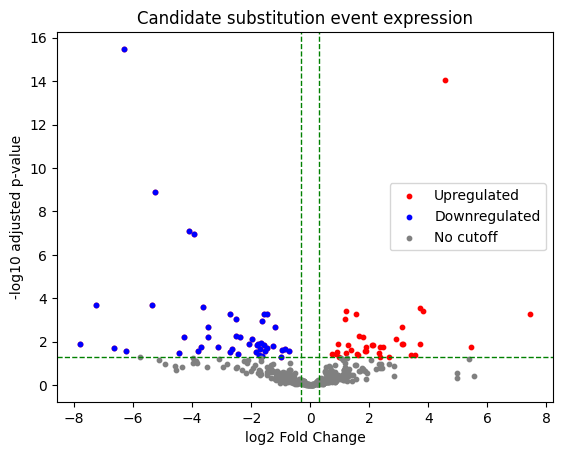

In [ ]:
## Running DE modules on healthy kideney tissues and RCC tissue, all independent patients
'''
# Opens up zip files (import gz files into local directory)
files1 = '/content/SRR11873712.fastq.gz'
files2 = '/content/SRR11873715.fastq.gz'
files3 = '/content/SRR11873716.fastq.gz'
files4 = '/content/SRR11873709.fastq.gz'
files5 = '/content/SRR11873710.fastq.gz'
files6 = '/content/SRR11873711.fastq.gz'
gz_files_list = [files1, files2, files3, files4, files5, files6]
expandGZ(gz_files_list)

# Trims the fastq files
adapter = 'TGGAATTCTCGGGTGCCAAGGAACTCCAG'
files1 = '/content/SRR11873712.fastq'
files2 = '/content/SRR11873715.fastq'
files3 = '/content/SRR11873716.fastq'
files4 = '/content/SRR11873709.fastq'
files5 = '/content/SRR11873710.fastq'
files6 = '/content/SRR11873711.fastq'
raw_files_list = [files1, files2, files3, files4, files5, files6]
trimmer(input_raw_files=raw_files_list, adapter=adapter, minLength=15, maxLength=30, adapter_Mismatch_Num=1, min_overlap_adapter_length=7)

# Collapses reads
files1 = '/content/trimmed_files_1_SRR11873712.fastq'
files2 = '/content/trimmed_files_2_SRR11873715.fastq'
files3 = '/content/trimmed_files_3_SRR11873716.fastq'
files4 = '/content/trimmed_files_4_SRR11873709.fastq'
files5 = '/content/trimmed_files_5_SRR11873710.fastq'
files6 = '/content/trimmed_files_6_SRR11873711.fastq'
trimmed_files_list = [files1, files2, files3, files4, files5, files6]
fqstQC(trimmed_files_list, '/content/fastqc_output')
collapse_reads(trimmed_files_list, inputFileType='fastq')

# Run Bowtie 2 on collapsed files
files1 = '/content/deduplicated_trimmed_files_1_SRR11873712.fasta'
files2 = '/content/deduplicated_trimmed_files_2_SRR11873715.fasta'
files3 = '/content/deduplicated_trimmed_files_3_SRR11873716.fasta'
files4 = '/content/deduplicated_trimmed_files_4_SRR11873709.fasta'
files5 = '/content/deduplicated_trimmed_files_5_SRR11873710.fasta'
files6 = '/content/deduplicated_trimmed_files_6_SRR11873711.fasta'
deduplicated_files_list = [files1, files2, files3, files4, files5, files6]
hsa1_ref = species_reference('/content/mature.fa', 'hsa') # Make mature align reference based on species
# Bowtie on the input files
bowtie(deduplicated_files_list, hsa1_ref, seedLength=7, num_mismatch_in_seed=1, num_return_align=1, align_style='--end-to-end')

# Setup SAM files
sam1 = '/content/bowtie1.sam'
sam2 = '/content/bowtie2.sam'
sam3 = '/content/bowtie3.sam'
sam4 = '/content/bowtie4.sam'
sam5 = '/content/bowtie5.sam'
sam6 = '/content/bowtie6.sam'
bowtie_list = [sam1, sam2, sam3, sam4, sam5, sam6]
# Make count and metadata files
postBowtie2(bowtie_list)
# Find align gene counts for all samples
aligned_genes = finding_total_aligned('/content/count_data_DE.csv')
# Run PyDESEq2
Deseq2('/content/count_data_DE.csv', '/content/metadata_DE.csv', 'Counts', list(aligned_genes.values()))
# Title of graph: RCC DE analysis
'''

In [ ]:
# Determines specific RCC miRNA genes to focus on
df = pd.read_csv('/content/stats_res.csv', index_col=0)
lists = np.array(df['log2FoldChange'])
# Counts how many upregulated and down regulated genes in the positive control samples
countPositive = np.sum(lists > 0)
countNegative = np.sum(lists < 0)
print(countPositive)
print(countNegative)

# Writes a csv file to determine if the genes selected for viewing are present
lists = ['hsa-miR-200c-3p', 'hsa-miR-362-5p', 'hsa-miR-363-3p', 'hsa-miR-204-5p', 'hsa-miR-21-5p', 'hsa-miR-224-5p', 'hsa-miR-155-5p', 'hsa-miR-210-3p']
df = df[df.index.isin(lists)]
df.to_csv('focusGenes.csv', index=True)


37
45


# Candidate mutation detection specific code

In [ ]:
# Setup Bowtie2 SAM files
sam1 = '/content/Bowtie1.sam'
sam2 = '/content/Bowtie2.sam'
sam3 = '/content/Bowtie3.sam'
sam4 = '/content/Bowtie4.sam'
sam5 = '/content/Bowtie5.sam'
sam6 = '/content/Bowtie6.sam'
sam_files = [sam1, sam2, sam3, sam4, sam5, sam6]
aligned_genes = finding_total_aligned('/content/count_data_DE.csv') # Assumming PostBowtie2 has been run
samAnalyzer(sam_files, aligned_genes) # Call samAnalyzer to determine candidate substitution events

911867
441733
363760
1008152
1247749
1617881
Saved normalized mutation data with single identifier column to all_mutations_normalized_single_column_id.csv


,Mutation_Identifier,Control1_normalized,Control2_normalized,Control3_normalized,High1_normalized,High2_normalized,High3_normalized
0,mmu-let-7a-1-3p | 1 | C-T,0.535,0.0,0.203,0.000,0.000,0.000
1,mmu-let-7a-1-3p | 2 | T-C,0.000,0.0,0.000,0.162,0.000,0.000
2,mmu-let-7a-1-3p | 4 | T-A,0.000,0.0,0.406,0.000,0.154,0.125
3,mmu-let-7a-1-3p | 4 | T-C,0.000,0.0,0.203,0.000,0.000,0.125
4,mmu-let-7a-1-3p | 5 | A-G,0.000,0.0,0.203,0.162,0.000,0.250


Saved raw mutation data with single identifier column to all_mutations_raw_single_column_id.csv


,Mutation_Identifier,Control1,Control2,Control3,High1,High2,High3
0,mmu-let-7a-1-3p | 1 | C-T,4,0,1,0,0,0
1,mmu-let-7a-1-3p | 2 | T-C,0,0,0,1,0,0
2,mmu-let-7a-1-3p | 4 | T-A,0,0,2,0,1,1
3,mmu-let-7a-1-3p | 4 | T-C,0,0,1,0,0,1
4,mmu-let-7a-1-3p | 5 | A-G,0,0,1,1,0,2


In [ ]:
# Recording substitution event counts, independent of position and particular sequence
df = pd.read_csv('all_mutations_combined.csv', index_col = 2)
df.drop(columns=['Position', 'miRNA'])
df = df.groupby('Ref_to_Alt', as_index=True).sum()
df.to_csv('adjustedBowtie1_events.csv', index=True)

In [ ]:
# Z-score heat maps of candidate substitution events, independent of position or sequence
zscore_all_samples = [] # Gets the Z score of each column
df = pd.read_csv('/content/adjustedBowtie1_events.csv', index_col=0)
dfzscores = pd.DataFrame(index =list(df.index) , columns=list(df.columns)) # List of all Z-scores

for samples in df.columns: #
  data = np.array(list(df.loc[:, samples])) # Sets up array
  z_scores = stats.zscore(data) # Calculates Z-score
  zscore_all_samples.append(z_scores) # Appends to list of all Z-scores
  dfzscores[samples] = z_scores # Sets a column with the values of Z-scores

# Sets the zscore events
df = dfzscores
df.index.name = 'Events' # Sets index column name

# Plots figures and sets heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    df,
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    linecolor="black",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Z-score"}
)
plt.title("Mutation Event Z-score Heatmap")
plt.xlabel("Samples")
plt.ylabel("Mutation Type")
plt.tight_layout()
plt.show()

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 23.60 seconds.

Fitting dispersion trend curve...
/usr/local/lib/python3.12/dist-packages/pydeseq2/dds.py:727: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.48 seconds.

Fitting MAP dispersions...
... done in 41.11 seconds.

Fitting LFCs...
... done in 21.49 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 5.13 seconds.



Log2 fold change & Wald test p-value: Types High vs Control
                           baseMean  log2FoldChange     lfcSE      stat  \
Mutation_Identifier                                                       
mmu-let-7a-1-3p | 1 | C-T  0.814208       -3.329455  3.462595 -0.961549   
mmu-let-7a-1-3p | 2 | T-C  0.173654        0.673641  4.427692  0.152143   
mmu-let-7a-1-3p | 4 | T-A  0.696711       -0.461876  2.068166 -0.223327   
mmu-let-7a-1-3p | 4 | T-C  0.335608       -0.288143  2.971465 -0.096970   
mmu-let-7a-1-3p | 5 | A-G  0.634003        1.149418  1.973272  0.582493   
...                             ...             ...       ...       ...   
mmu-miR-9b-3p | 21 | A-C   2.182410        1.039102  1.072862  0.968533   
mmu-miR-9b-3p | 21 | A-G   4.455588        0.233395  0.692361  0.337101   
mmu-miR-9b-3p | 21 | A-T   5.687266       -0.456205  0.816396 -0.558803   
mmu-miR-9b-5p | 3 | C-T    0.323891        1.665284  3.274743  0.508524   
mmu-miR-9b-5p | 10 | C-A   0.210866     

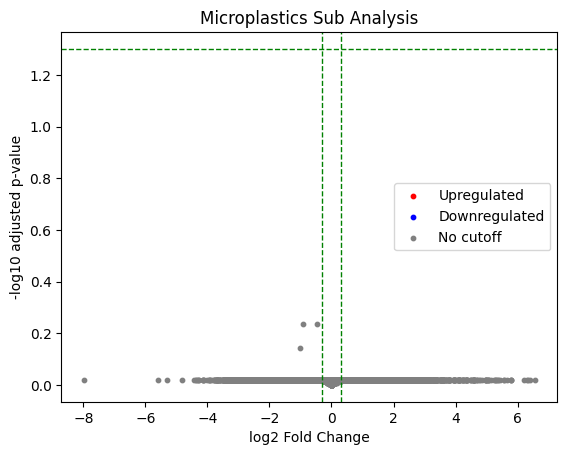

In [ ]:
# PyDESeq2 analysis on individual mutation event groups
Deseq2('/content/all_mutations_raw_single_column_id.csv', '/content/metadata_DE.csv', 'Mut', aligned_genes)

In [ ]:
# Random selection of 50 internal isomiR genes to select for a 1 million seq sample
import random
sequences = [
    "TGAGGTGGTAGGTTGTATAGTT",
    "TATTGCACTTGCCCCGGCCTGT",
    "TATTGCGCTTGTCCCGGCCTGT",
    "TGTTGCACTTGTCCCGGCCTGT",
    "TACTGCACTTGTCCCGGCCTGT",
    "TATTGCACTTGTCCCGACCTGT",
    "TATTGCACTTGTCCCAGCCTGT",
    "TATTGCACTTGTCCCGGCCCGT",
    "CGAGGTAGTAGGTTGTATAGTT",
    "CATTGCACTTGTCCCGGCCTGT",
    "AAGCTGCCAGTTGAAGAATTGT",
    "TGAGGTAGTAGGTTGTATAGCT",
    "TATTGCACTTGTCACGGCCTGT",
    "AAGCTGCTAGTTGAAGAACTGT",
    "AATTGCACTTGTCCCGGCCTGT",
    "GAGCTGCCAGTTGAAGAACTGT",
    "TATTGCACTTGTCTCGGTCTGA",
    "TATTGCACTTGTCCCTGCCTGT",
    "AGGCTGCCAGTTGAAGAACTGT",
    "TGAGGGAGTAGGTTGTATAGTT",
    "TGAGGTAGTAGGTCGTATAGTT",
    "TATTACACTTGTCCCGGCCTGT",
    "AAGCTGTCAGTTGAAGAACTGT",
    "TCTCACTGTAGCATCGAACCCC",
    "TATTGCACTTGTCCCGGTCTGT",
    "AAGCTGCCAGTCGAAGAACTGT",
    "TGAGGCAGTAGATTGTATAGTT",
    "AAGCCGCCAGTTGAAGAACTGT",
    "AAGCTGCCAGTTGAGGAACTGT",
    "AAGCTGCCGGTTGAAGAACTGT",
    "CATTGCACTTGTCTCGGCCTGA",
    "TGAGGGAGTAGATTGTATAGTT",
    "TGAGGAAGTAGGTTGTATAGTT",
    "AAGCTGCCAGTTGGAGAACTGT",
    "AAGCTGCCAGCTGAAGAACTGT",
    "AAGCTGCCAGTTGAAGGACTGT",
    "AAGCTACCAGTTGAAGAACTGT",
    "TAAGGTAGTAGGTTGTATAGTT",
    "TATTGCACTTGTCCAGGCCTGT",
    "TATTGCACTTATCCCGGCCTGT",
    "TATTGCACTTGTTCCGGCCTGT",
    "TATTGCACTTGTCTCGGCCTGT",
    "TGGGGTAGTAGGTTGTATAGTT",
    "TGAGGTAGTAGGCTGTATAGTT",
    "TATTGCACTTGTCCTGGCCTGT",
    "TGAGGCAGTAGGTTGTATAGTT",
    "TATTGTACTTGTCCCGGCCTGT",
    "TATCGCACTTGTCCCGGCCTGT",
    "TATTGCACTTGTCCCGGCCTAT",
    "TGAGGTAGTGGGTTGTATAGTT"
] # 50 internal isomiRs, with one substitution event per sequence

# Write 1 million sequences, randomly selected from the 50 isomiR list
with open('testSNVfasta.fasta', 'w') as f:
  for i in range(0, 1000000):
    sequence = random.choice(sequences)
    f.write(f'Seq{i+1}\n{sequence}\n')

In [ ]:
# Bowtie on the artificial fasta files
!pip install biopython
from collections import defaultdict
from Bio import SeqIO
hsa_mature = '/content/hsaMaturemiRNA.fasta'
collapse_reads(['/content/testSNVfasta.fasta'], 'fasta')
bowtie(['deduplicatedtestSNVfasta.fasta'], aligner=hsa_mature, seedLength=7, num_mismatch_in_seed=1, num_return_align=1, align_style='--end-to-end')

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:7 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.6 MB]
Fetched 10.6 MB in 3s (4,247 kB/s)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
193 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy 